# Analyse et Prédiction des Retards de Vol

Ce notebook contient toutes les étapes d'analyse exploratoire, de préparation et de modélisation sur le jeu de données des retards d'avion.

## 1. Import des librairies

In [25]:
# %pip install pandas numpy matplotlib seaborn missingno lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
%matplotlib inline

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.metrics import classification_report

## 2. Chargement des données

- Voir journal de bord pour process complet : Requiere d'avoir généré le fichier all_cleaned.parquet
- Le trie des données est réalisé à l'aide d'une données Json qui contient les information des colonnes de l'ensemble du dataset (database\flights\data\dataset_description.json)Pour chaque données, j'ai mis la description pour celles qui n'étaient pas dans le brif, une entrée indiquant si la clé est dans le brief ou pas et une clé pour choisir d'utiliser ou non la colonne.
- Exemple : FL_NUM est le numéro du vol, il n'a aucun sens pour la prédiction des retards, donc on ne l'utilise pas dans le modèle ("keep": false) mais il était décris dans le brief ("is_describe_in_topic": true).

```json
{
    "name": "FL_NUM",
    "description": "Numéro du vol -- A part si on est supersticieux y'a pas de raison de le garder",
    "type": "int",
    "keep": false,
    "is_describe_in_topic": true
}
```

- Pour alléger un peu le volume de données agrégé, j'ai fait le choix de partir d'un premier filtre avec uniquement les colonnes pointées du brief, qui donc correspondent aux données brutes pour moi (database\flights\data\processed\all_from_subject.parquet). 
- Ensuite depuis ce pool, je ne garde que les colonnes keep = true pour arriver à un dataset de prédiction correcte.
- La justification des choix de conserver ou non la données a été indiqué dans la description de chaque colonne dans le fichier JSON.
- Globalement nous n'avons pas de données personnelles sensibles au sens **RGPD**, mais il y a des données qui peuvent être considérées comme fortement identifiante (numéro de vol par exemple) et qui sont donc supprimées du dataset final (En plus de n'avoir aucun sens statistique).
- Toute une partie des données a été retiré car elle procurait un biais de prediction ; Toutes les informations horaires à partir du décollage de l'avion biase la prédiction
- Il est important dans un jeu de données de ce type de faire attention aux biais géographiques ou saisonnier que l'on peux introduire dans le modèle. Il ne faut pas discriminer un aéroport, une compagnie aérienne ou une période de l'année.
- => L'ensemble de ces étapes permettent de produire le fichier *all_cleaned.parquet* qui est le dataset de base pour la suite de l'analyse.

In [2]:
# Chargement et aperçu du fichier nettoyé
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

- On en profite pour faire un sample de 100 000 lignes pour faire les tests de nettoyage et d'analyse en prenant soin de garder la répartition des retards.
- Et ce sample servira pour l'entrainement pour gagner en temps d'apprentissage

In [19]:
# Échantillon équilibré 50/50 selon la répartition de ARR_DEL15
n = 50000  # nombre d'échantillons par classe pour 100000 au total
df_0 = df_clean[df_clean['ARR_DEL15'] == 0].sample(n=n, random_state=42)
df_1 = df_clean[df_clean['ARR_DEL15'] == 1].sample(n=n, random_state=42)
df_sample = pd.concat([df_0, df_1]).sample(frac=1, random_state=42)  # mélange

# Vérification de la proportion
print(df_sample['ARR_DEL15'].value_counts(normalize=True))
print(df_sample.shape)
df_sample.head()


ARR_DEL15
True     0.5
False    0.5
Name: proportion, dtype: Float64
(100000, 15)


,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME
1889267,3,2016-05-25,WN,19393,MDW,DAL,1815,2159,224.0,True,15.0,2214,2035,True,140.0
3219235,3,2016-08-03,B6,20409,LAS,LGB,1625,1830,125.0,True,12.0,1842,1731,True,66.0
2033916,1,2016-05-02,UA,19977,ORD,TPA,1751,1752,1.0,False,24.0,1816,2133,False,162.0
3015969,5,2016-07-08,NK,20416,MSP,BWI,1620,1743,83.0,True,15.0,1758,1945,True,145.0
2374904,7,2016-06-26,WN,19393,LAS,ATL,1840,1904,24.0,True,15.0,1919,130,True,230.0


## 3. Exploration des données

In [8]:
# Aperçu des premières lignes
df_clean.head()

,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME
0,3,2016-01-06,AA,19805,DFW,DTW,1100,1057,-3.0,False,15.0,1112,1438,False,158.0
1,4,2016-01-07,AA,19805,DFW,DTW,1100,1056,-4.0,False,14.0,1110,1438,False,158.0
2,5,2016-01-08,AA,19805,DFW,DTW,1100,1055,-5.0,False,21.0,1116,1438,False,158.0
3,6,2016-01-09,AA,19805,DFW,DTW,1100,1102,2.0,False,13.0,1115,1438,False,158.0
4,7,2016-01-10,AA,19805,DFW,DTW,1100,1240,100.0,True,20.0,1300,1438,True,158.0


In [9]:
# Dimensions du dataset
df_clean.shape

(5436679, 15)

In [10]:
# Types de variables
df_clean.dtypes

DAY_OF_WEEK                  Int64
FL_DATE             datetime64[ns]
UNIQUE_CARRIER              object
AIRLINE_ID                   Int64
ORIGIN                      object
DEST                        object
CRS_DEP_TIME                 Int64
DEP_TIME                     Int64
DEP_DELAY                  float64
DEP_DEL15                  boolean
TAXI_OUT                   float64
WHEELS_OFF                   Int64
CRS_ARR_TIME                 Int64
ARR_DEL15                  boolean
CRS_ELAPSED_TIME           float64
dtype: object

In [18]:
# Statistiques descriptives
df_clean.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
DAY_OF_WEEK,5436679.0,<NA>,<NA>,<NA>,3.930451,1.0,2.0,4.0,6.0,7.0,1.985595
FL_DATE,5436679,NaN,NaN,NaN,2016-07-03 20:25:10.176929280,2016-01-01 00:00:00,2016-04-04 00:00:00,2016-07-06 00:00:00,2016-10-01 00:00:00,2016-12-31 00:00:00,NaN
UNIQUE_CARRIER,5436679,12,WN,1277915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRLINE_ID,5436679.0,<NA>,<NA>,<NA>,19897.112815,19393.0,19790.0,19805.0,20304.0,21171.0,380.154202
ORIGIN,5436679,311,ATL,375016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEST,5436679,310,ATL,374588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRS_DEP_TIME,5436679.0,<NA>,<NA>,<NA>,1330.01139,1.0,915.0,1325.0,1735.0,2359.0,489.190831
DEP_TIME,5436679.0,<NA>,<NA>,<NA>,1333.458187,1.0,917.0,1328.0,1742.0,2400.0,502.30195
DEP_DELAY,5436679.0,NaN,NaN,NaN,8.468584,-50.0,-5.0,-2.0,6.0,500.0,34.390775
DEP_DEL15,5436679,2,False,4505013,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Vérification des valeurs manquantes
df_clean.isnull().sum() if df_clean is not None else 'Données non chargées'

DAY_OF_WEEK         0
FL_DATE             0
UNIQUE_CARRIER      0
AIRLINE_ID          0
ORIGIN              0
DEST                0
CRS_DEP_TIME        0
DEP_TIME            0
DEP_DELAY           0
DEP_DEL15           0
TAXI_OUT            0
WHEELS_OFF          0
CRS_ARR_TIME        0
ARR_DEL15           0
CRS_ELAPSED_TIME    0
dtype: int64

## 4. Visualisations

<Axes: >

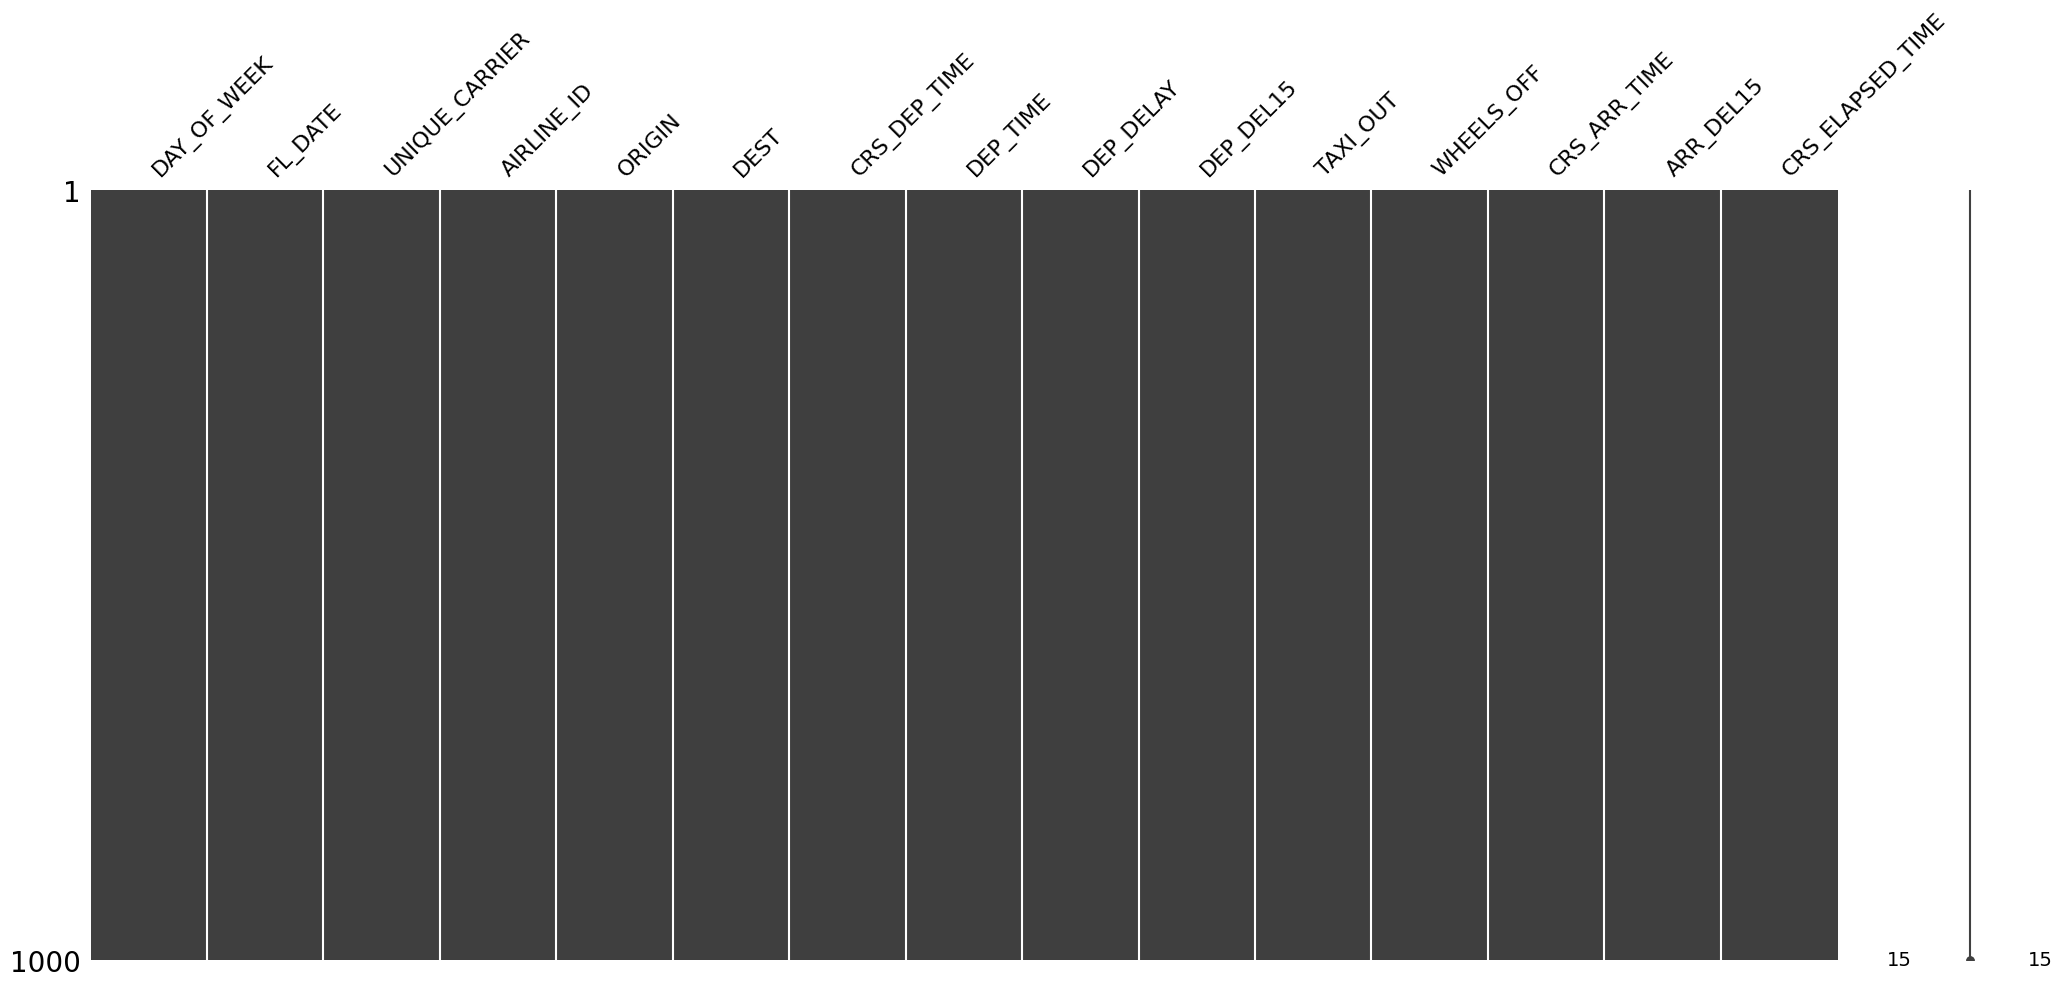

In [13]:
msno.matrix(df_clean.sample(1000))

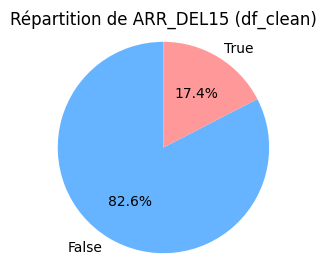

In [20]:
# Visualisation camembert de la répartition de ARR_DEL15 sur df_clean


arr_samp_del15_counts = df_clean['ARR_DEL15'].value_counts(dropna=False)
labels = arr_samp_del15_counts.index.astype(str)
plt.figure(figsize=(3, 3))
plt.pie(arr_samp_del15_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999','#99ff99','#ffcc99'])
plt.title('Répartition de ARR_DEL15 (df_clean)')
plt.axis('equal')
plt.show()

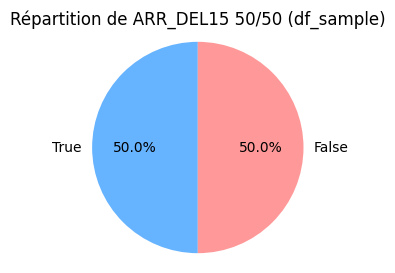

In [21]:
# Visualisation camembert de la répartition de ARR_DEL15 sur df_clean


arr_samp_del15_counts = df_sample['ARR_DEL15'].value_counts(dropna=False)
labels = arr_samp_del15_counts.index.astype(str)
plt.figure(figsize=(3, 3))
plt.pie(arr_samp_del15_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999','#99ff99','#ffcc99'])
plt.title('Répartition de ARR_DEL15 50/50 (df_sample)')
plt.axis('equal')
plt.show()

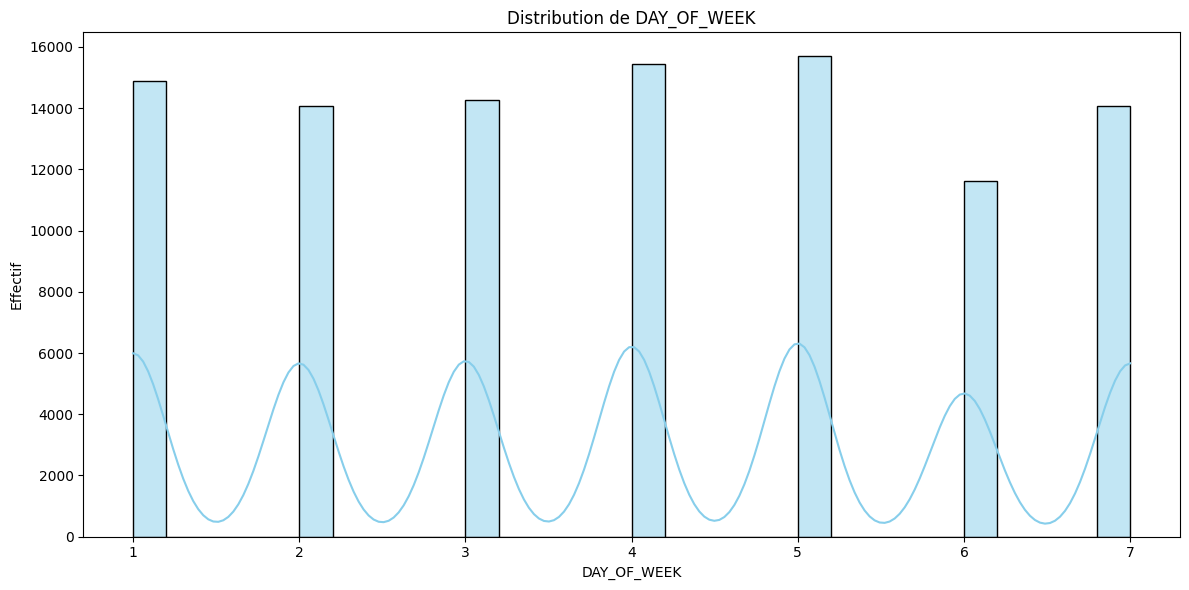

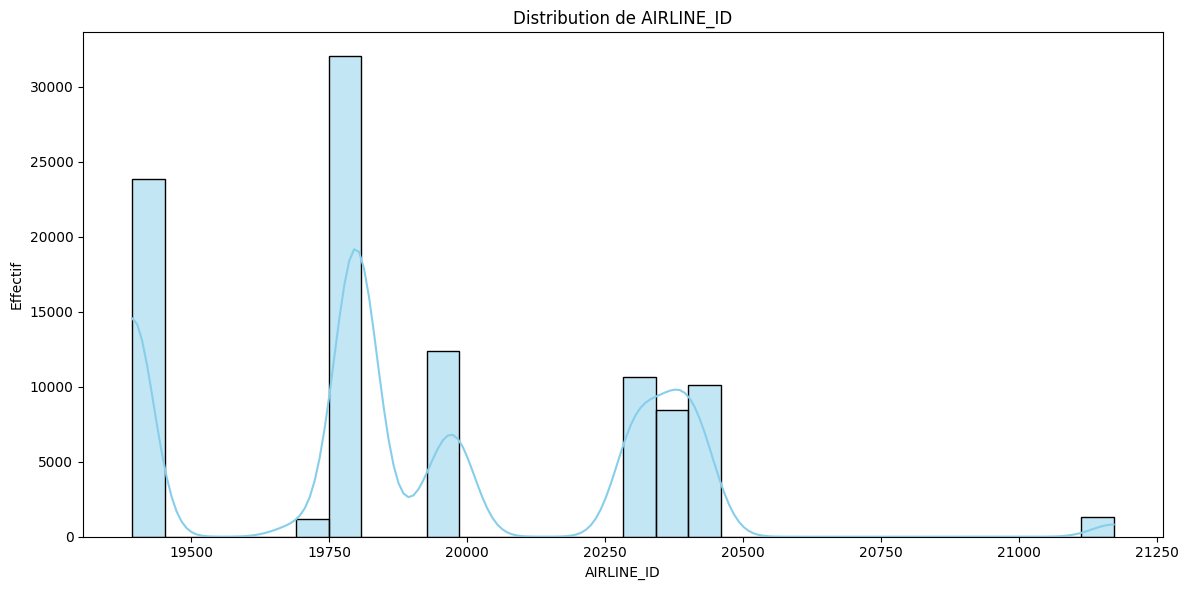

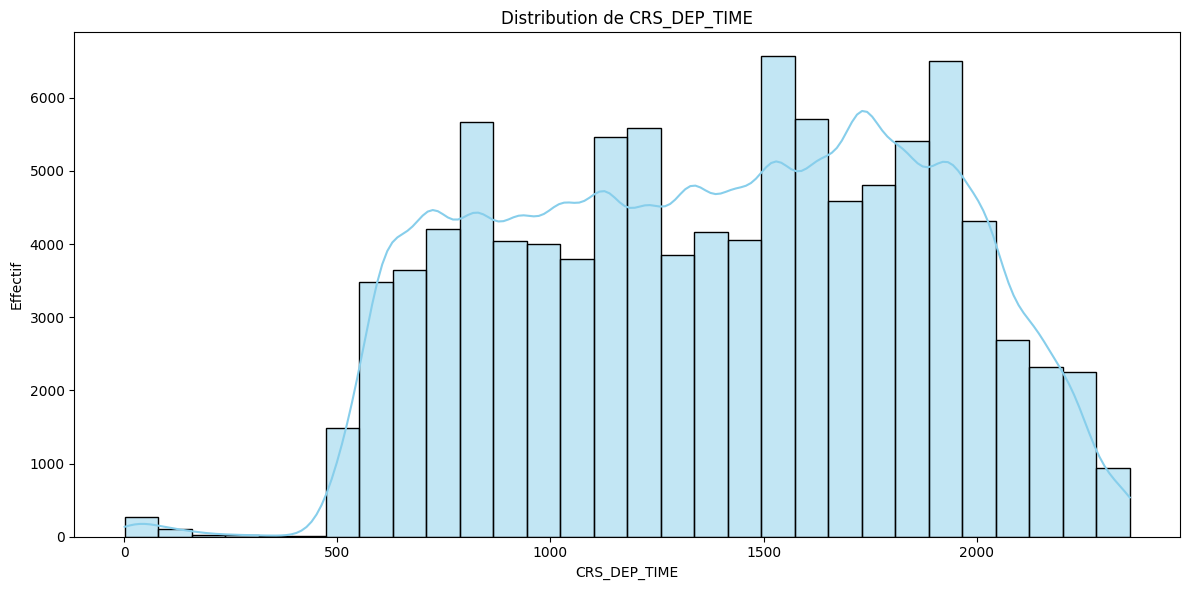

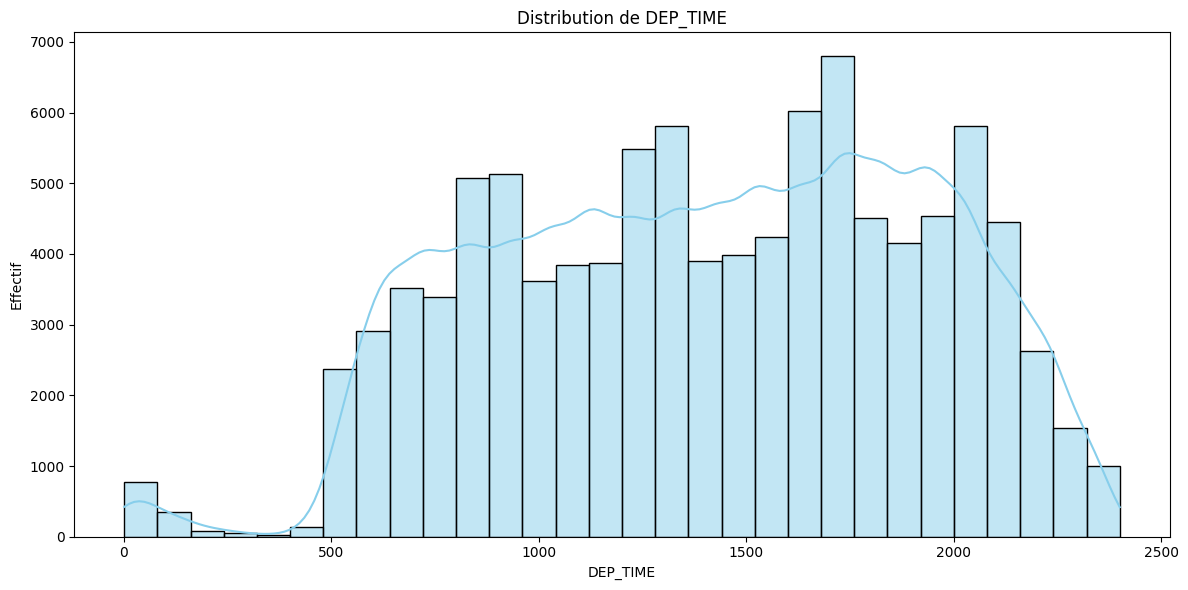

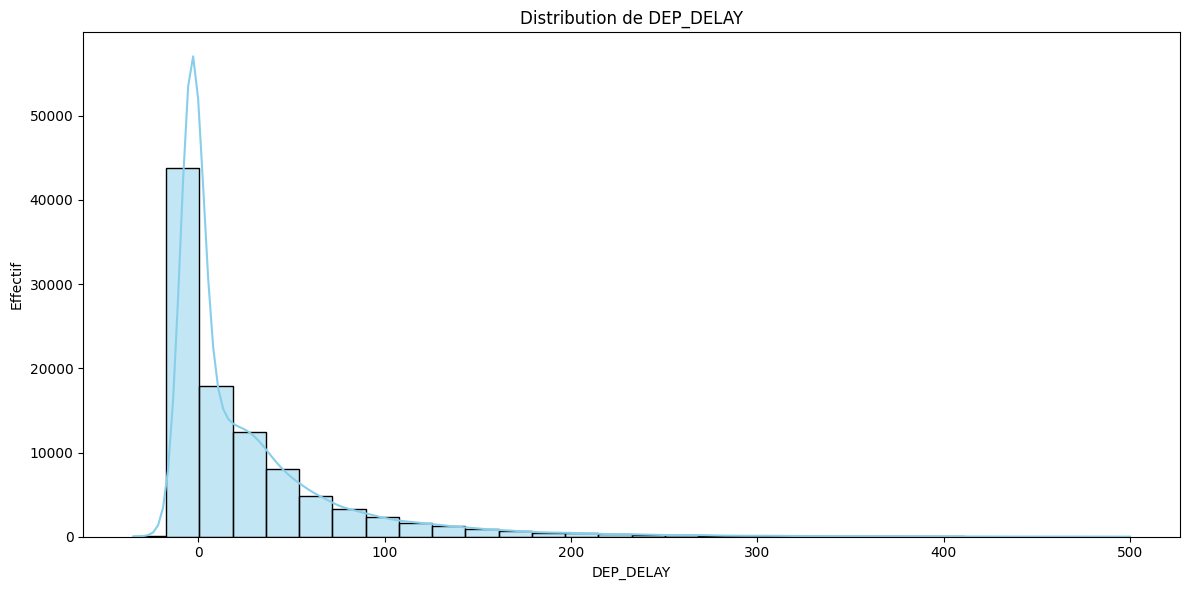

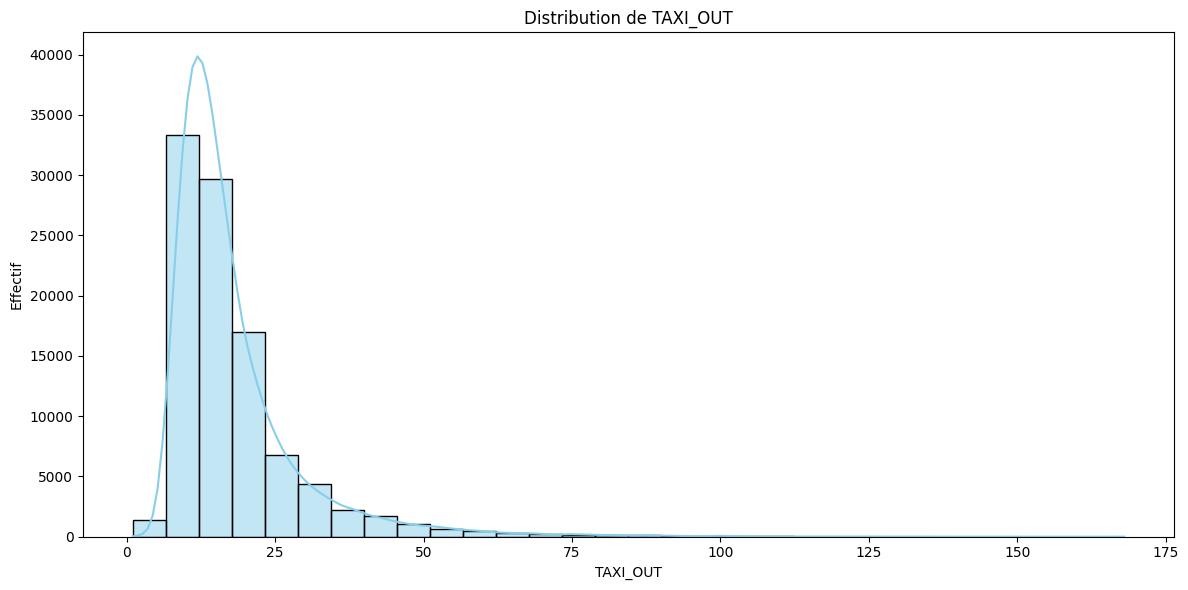

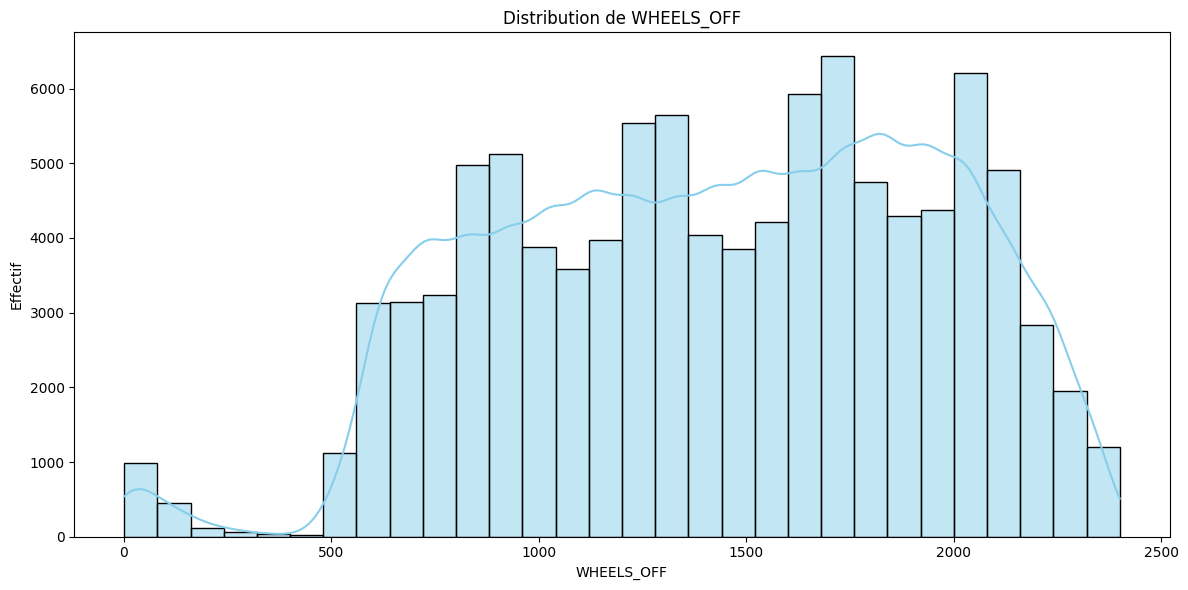

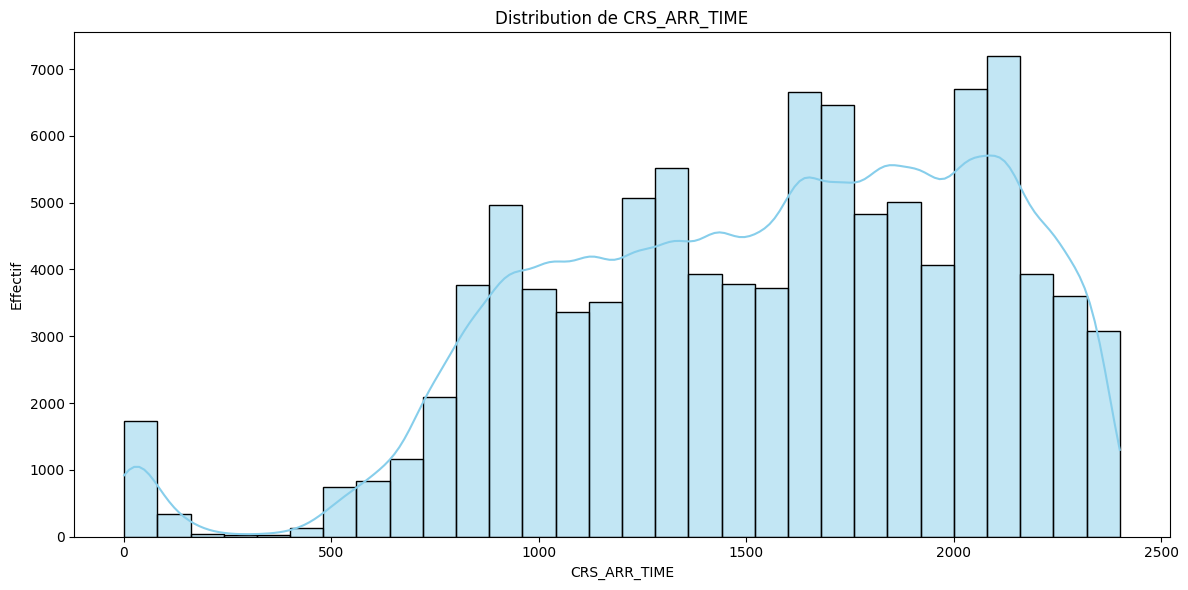

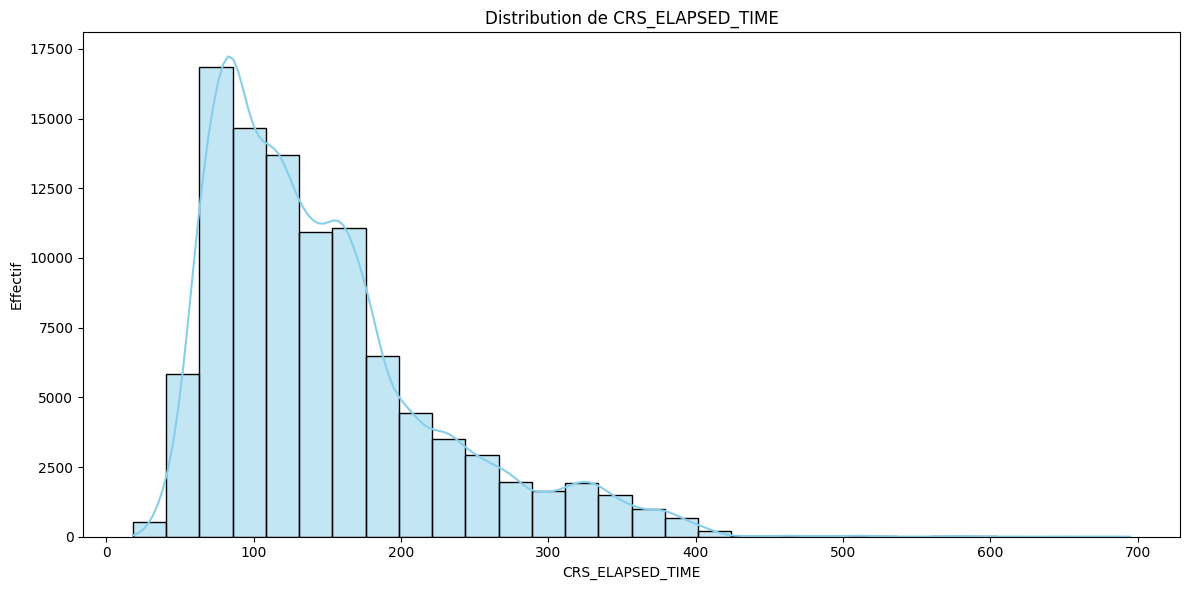

In [22]:
# Analyse des outliers sur les colonnes numériques
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Visualisation des distributions
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df_sample[col].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()

## 5. Modélisation

In [30]:
# Model choisi : LightGBMClassifier Gradiant Boosting


sample_train = df_sample.copy()

# Conversion du datetime en timestamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# test context : 
# sample_train = sample_train.sample(n=10000, random_state=42)

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)
X = sample_train.drop(columns=['ARR_DEL15'])

# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle LightGBM
lgb_clf = lgb.LGBMClassifier(random_state=42, n_estimators=100)
lgb_clf.fit(X_train_scaled, y_train)


# Prédiction des classes
y_pred = lgb_clf.predict(X_test_scaled)


# Prédiction des probabilités
lgb_pred_prob = lgb_clf.predict_proba(X_test_scaled)

# Score AUC
lgb_auc_score = roc_auc_score(y_test, lgb_pred_prob[:,1])
print(f"AUC score (LightGBM) : {lgb_auc_score:.4f}")

# Rapport de classification
print(f"Classification LightGBM : \n{classification_report(y_test, y_pred, digits=3)}")

[LightGBM] [Info] Number of positive: 34906, number of negative: 35094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3087
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 399
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498657 -> initscore=-0.005371
[LightGBM] [Info] Start training from score -0.005371


e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


AUC score (LightGBM) : 0.9672
Classification LightGBM : 
              precision    recall  f1-score   support

           0      0.888     0.938     0.913     14906
           1      0.935     0.884     0.909     15094

    accuracy                          0.911     30000
   macro avg      0.912     0.911     0.911     30000
weighted avg      0.912     0.911     0.911     30000



In [32]:
X

,DAY_OF_WEEK,FL_DATE,AIRLINE_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,TAXI_OUT,WHEELS_OFF,CRS_ARR_TIME,...,DEST_TYR,DEST_TYS,DEST_UST,DEST_VLD,DEST_VPS,DEST_WRG,DEST_WYS,DEST_XNA,DEST_YAK,DEST_YUM
1889267,3,1464134400,19393,1815,2159,224.0,True,15.0,2214,2035,...,False,False,False,False,False,False,False,False,False,False
3219235,3,1470182400,20409,1625,1830,125.0,True,12.0,1842,1731,...,False,False,False,False,False,False,False,False,False,False
2033916,1,1462147200,19977,1751,1752,1.0,False,24.0,1816,2133,...,False,False,False,False,False,False,False,False,False,False
3015969,5,1467936000,20416,1620,1743,83.0,True,15.0,1758,1945,...,False,False,False,False,False,False,False,False,False,False
2374904,7,1466899200,19393,1840,1904,24.0,True,15.0,1919,130,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4136066,1,1477872000,19790,1115,1109,-6.0,False,14.0,1123,1345,...,False,False,False,False,False,False,False,False,False,False
666529,1,1455494400,19790,1444,1456,12.0,False,31.0,1527,1639,...,False,False,False,False,False,False,False,False,False,False
286338,5,1454025600,20366,2115,2138,23.0,True,11.0,2149,2214,...,False,False,False,False,False,False,False,False,False,False
1992459,1,1463961600,20416,614,615,1.0,False,19.0,634,845,...,False,False,False,False,False,False,False,False,False,False


In [33]:
# Détection automatique des colonnes numériques et catégorielles
colonnes_numeriques = X.select_dtypes(include=[np.number]).columns.tolist()
colonnes_categorielles = X.select_dtypes(exclude=[np.number]).columns.tolist()

colonnes_numeriques

['DAY_OF_WEEK',
 'FL_DATE',
 'AIRLINE_ID',
 'CRS_DEP_TIME',
 'DEP_TIME',
 'DEP_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'CRS_ARR_TIME',
 'CRS_ELAPSED_TIME']

In [34]:
colonnes_categorielles

['DEP_DEL15',
 'UNIQUE_CARRIER_AS',
 'UNIQUE_CARRIER_B6',
 'UNIQUE_CARRIER_DL',
 'UNIQUE_CARRIER_EV',
 'UNIQUE_CARRIER_F9',
 'UNIQUE_CARRIER_HA',
 'UNIQUE_CARRIER_NK',
 'UNIQUE_CARRIER_OO',
 'UNIQUE_CARRIER_UA',
 'UNIQUE_CARRIER_VX',
 'UNIQUE_CARRIER_WN',
 'ORIGIN_ABI',
 'ORIGIN_ABQ',
 'ORIGIN_ABR',
 'ORIGIN_ABY',
 'ORIGIN_ACK',
 'ORIGIN_ACT',
 'ORIGIN_ACV',
 'ORIGIN_ACY',
 'ORIGIN_ADQ',
 'ORIGIN_AEX',
 'ORIGIN_AGS',
 'ORIGIN_ALB',
 'ORIGIN_AMA',
 'ORIGIN_ANC',
 'ORIGIN_APN',
 'ORIGIN_ASE',
 'ORIGIN_ATL',
 'ORIGIN_ATW',
 'ORIGIN_AUS',
 'ORIGIN_AVL',
 'ORIGIN_AVP',
 'ORIGIN_AZO',
 'ORIGIN_BDL',
 'ORIGIN_BET',
 'ORIGIN_BFL',
 'ORIGIN_BGM',
 'ORIGIN_BGR',
 'ORIGIN_BHM',
 'ORIGIN_BIL',
 'ORIGIN_BIS',
 'ORIGIN_BJI',
 'ORIGIN_BLI',
 'ORIGIN_BMI',
 'ORIGIN_BNA',
 'ORIGIN_BOI',
 'ORIGIN_BOS',
 'ORIGIN_BPT',
 'ORIGIN_BQK',
 'ORIGIN_BQN',
 'ORIGIN_BRD',
 'ORIGIN_BRO',
 'ORIGIN_BRW',
 'ORIGIN_BTM',
 'ORIGIN_BTR',
 'ORIGIN_BTV',
 'ORIGIN_BUF',
 'ORIGIN_BUR',
 'ORIGIN_BWI',
 'ORIGIN_BZN',
 'ORIGIN_

In [ ]:
# Pipeline LightGBM avec preprocessing numérique et catégoriel
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd


# Model choisi : LightGBMClassifier Gradiant Boosting


sample_train = df_sample.copy()

# Conversion du datetime en timestamp pour garder une information temporelle
sample_train["FL_DATE"] = sample_train["FL_DATE"].astype("int64") // 10**9  # en secondes

# test context : 
# sample_train = sample_train.sample(n=10000, random_state=42)

# Préparation des données : X = toutes les colonnes sauf ARR_DEL15, y = ARR_DEL15
y = sample_train['ARR_DEL15'].astype(int)
X = sample_train.drop(columns=['ARR_DEL15'])

# Encodage des variables catégorielles (one-hot)
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Détection automatique des colonnes numériques et catégorielles
colonnes_numeriques = X.select_dtypes(include=[np.number]).columns.tolist()
colonnes_categorielles = X.select_dtypes(exclude=[np.number]).columns.tolist()



def build_pipeline(col_num, col_cat):
    preprocesseur = ColumnTransformer([
        ('num', StandardScaler(), col_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), col_cat)
    ])
    modele = LGBMClassifier(n_estimators=300, learning_rate=0.1, random_state=42)
    return Pipeline([
        ('preprocessing', preprocesseur),
        ('clf', modele)
    ])

pipeline = build_pipeline(colonnes_numeriques, colonnes_categorielles)
pipeline.fit(X_train, y_train)
print(classification_report(y_test, pipeline.predict(X_test)))

### Sauvegarde du modèle

In [31]:
# Sauvegarde du modèle LightGBM entraîné
import joblib
joblib.dump(lgb_clf, "model_lightgbm_retards_avion.joblib")
print("Modèle LightGBM sauvegardé : 'model_lightgbm_retards_avion.joblib'")

Modèle LightGBM sauvegardé : 'model_lightgbm_retards_avion.joblib'


# Mise en production

Ce projet met en place une architecture complète pour le déploiement, le suivi et la supervision d’un service de machine learning autour des retards de vols. Il s’appuie sur Docker et docker-compose pour orchestrer l’ensemble des composants, facilitant la portabilité et la reproductibilité.

## Mise en production et infrastructure :

L’application est découpée en plusieurs services : 
- backend (API ML)
- frontend (interface utilisateur)
- base de données (MySQL)
- orchestration de workflows (Prefect)
- suivi d’expériences (MLflow)
- monitoring (Prometheus, Grafana, Node Exporter)
- supervision de disponibilité (Uptime Kuma)
- CI/CD avec GitHub Actions pour maintenance d'images dockers et l'execution des tests unitaires
  
Chaque service est isolé dans un conteneur dédié, ce qui permet une gestion indépendante, une meilleure sécurité et une scalabilité facilitée.
Les volumes Docker assurent la persistance des données (modèles, logs, artefacts MLflow, base MySQL, etc.) même en cas de redémarrage des conteneurs.
Les variables d’environnement et fichiers .env permettent de configurer dynamiquement les ports, URLs, et secrets sans modifier le code source.

## Suivi, monitoring et observabilité :

**MLflow** est utilisé pour le suivi des expériences, la gestion des modèles et des artefacts de machine learning
**Prometheus** collecte les métriques des services (API, système, etc.) et **Grafana** permet de visualiser ces métriques via des dashboards personnalisés
**Node Exporter** expose les métriques système de la machine hôte
**Uptime Kuma** surveille la disponibilité des services et alerte en cas d’indisponibilité.

Les logs de chaque service sont montés sur le système de fichiers pour faciliter l’audit et le debug.

## Orchestration et automatisation :

**Prefect** orchestre les workflows de traitement de données et de réentrainement des modèles, avec une interface de gestion centralisée.
Les dépendances entre services sont gérées par docker-compose (depends_on), assurant le bon ordre de démarrage.

## Sécurité et bonnes pratiques :

Les accès sensibles sont gérés par variables d’environnement.
L’architecture en réseau privé Docker (app_network) isole les communications entre services.
